In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from factor_analyzer import FactorAnalyzer
import semopy 

1. Cargue la base de datos y realice los ajustes necesarios para su uso (missing values, recodificar variables, etcetera). Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario.

In [24]:
data = pd.read_csv("../data/junaeb3.csv");
data.dropna(inplace=True);
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29696 entries, 1 to 31054
Data columns (total 23 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   sexo        29696 non-null  int64  
 1   edad        29696 non-null  int64  
 2   imce        29696 non-null  float64
 3   vive_padre  29696 non-null  int64  
 4   vive_madre  29696 non-null  int64  
 5   sk1         29696 non-null  int64  
 6   sk2         29696 non-null  int64  
 7   sk3         29696 non-null  int64  
 8   sk4         29696 non-null  int64  
 9   sk5         29696 non-null  int64  
 10  sk6         29696 non-null  int64  
 11  sk7         29696 non-null  int64  
 12  sk8         29696 non-null  int64  
 13  sk9         29696 non-null  int64  
 14  sk10        29696 non-null  int64  
 15  sk11        29696 non-null  int64  
 16  sk12        29696 non-null  int64  
 17  sk13        29696 non-null  int64  
 18  act_fisica  29696 non-null  float64
 19  area        29696 non-null  in

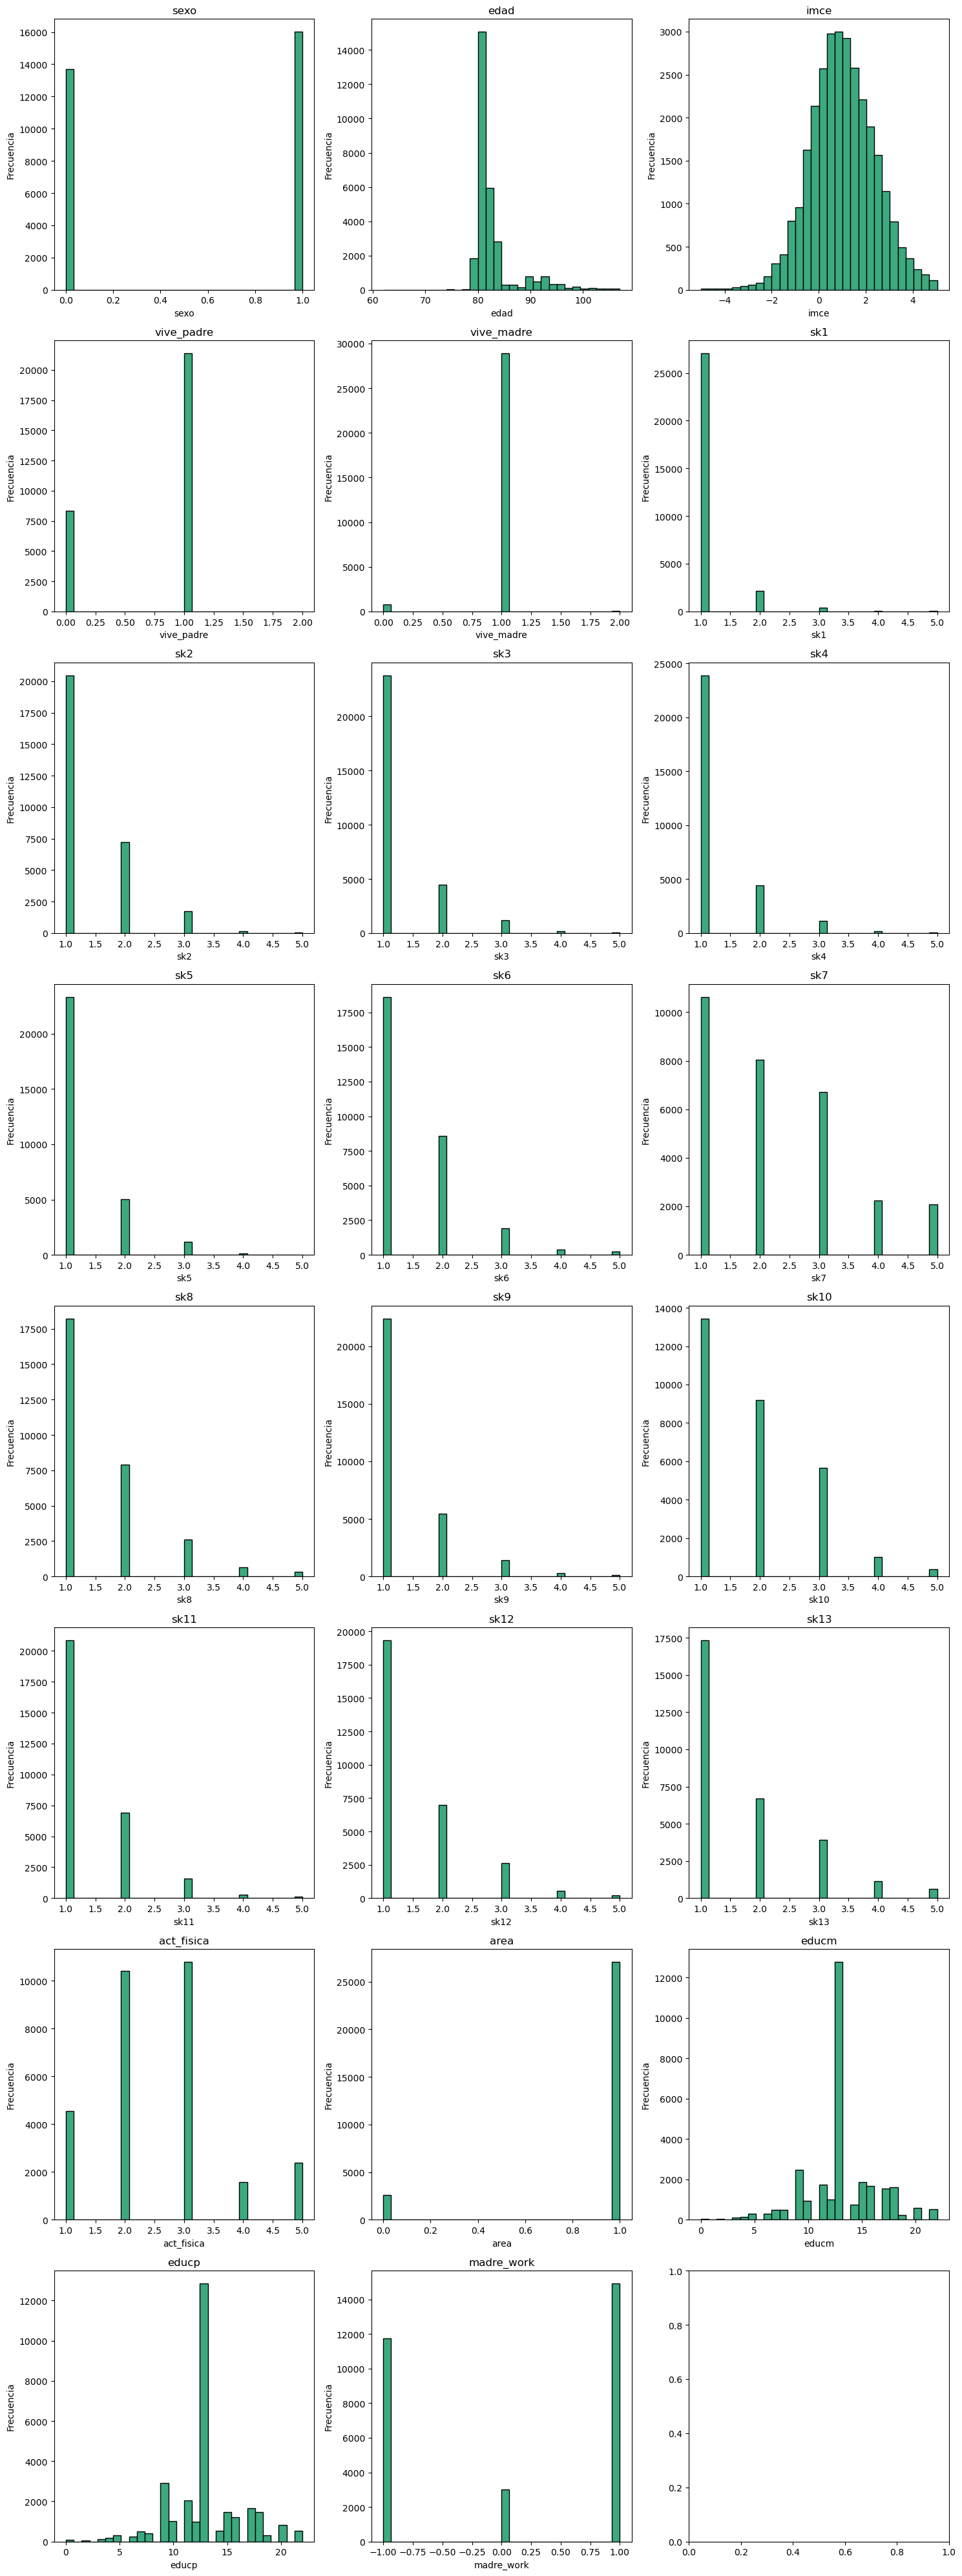

In [25]:
numerical_columns = data.select_dtypes(include='number').columns;
num_columns = len(numerical_columns);
fig, axs = plt.subplots((num_columns + 2) // 3, 3, figsize=(15, (num_columns + 2) // 3 * 5));
for i, column in enumerate(numerical_columns):
    ax = axs[i // 3, i % 3];
    ax.hist(data[column], bins=30, color='#3CA97E', edgecolor='black');
    ax.set_title(f'{column}');
    ax.set_xlabel(column);
    ax.set_ylabel('Frecuencia');
plt.tight_layout();
plt.show()

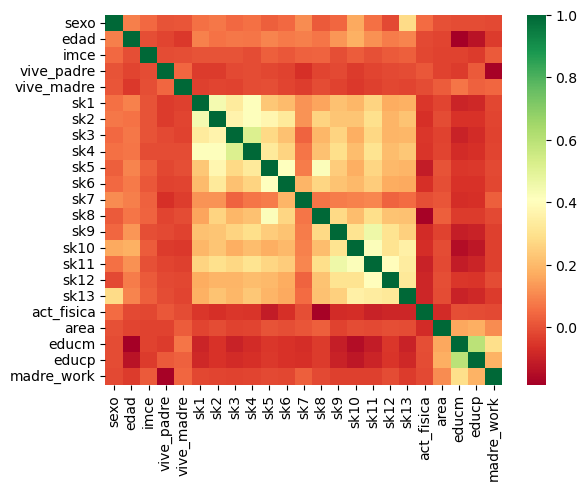

In [26]:
sns.heatmap(data.corr(), cmap='RdYlGn');

In [27]:
data_sk=data[['sk1','sk2','sk3','sk4','sk5','sk6','sk8','sk9','sk10','sk11','sk12','sk13']]
fa = FactorAnalyzer(rotation='oblimin', n_factors=3).fit(data_sk);
np.set_printoptions(suppress=True, formatter={'float_kind':'{:f}'.format})
fa.loadings_

array([[0.025091, 0.592769, -0.036490],
       [0.014132, 0.504176, 0.201440],
       [0.015141, 0.633897, -0.014981],
       [0.001552, 0.742733, -0.011935],
       [-0.030999, 0.020518, 0.804761],
       [0.081477, 0.098873, 0.419382],
       [0.231480, -0.072300, 0.454024],
       [0.502530, 0.074356, 0.049459],
       [0.610043, -0.023017, -0.033028],
       [0.704005, 0.033629, 0.005354],
       [0.570888, -0.038834, 0.007890],
       [0.508570, 0.028714, -0.008627]])

In [28]:
values = np.arange(1,13;
eigenvalues = pd.DataFrame(data=fa.get_eigenvalues());
plt.plot(values, eigenvalues.loc[0], 'o-', linewidth=2, color='blue');
plt.title('Scree Plot')
plt.xlabel('Factor')
plt.ylabel('Eigenvalue')
plt.show()

SyntaxError: invalid syntax (2156768608.py, line 1)

### Las dos celdas siguientes son opcionales para entender como explorar CFA con otros metodos

In [ ]:
from factor_analyzer import (ConfirmatoryFactorAnalyzer, ModelSpecificationParser)
model_dict = {"F2": ["sk1", "sk2", "sk3", "sk4"],
              "F1": ["sk5", "sk6", "sk8"],
              "F3": ["sk9", "sk10", "sk11", "sk12", "sk13"]}
model_spec = ModelSpecificationParser.parse_model_specification_from_dict(data_sk, model_dict)
cfa = ConfirmatoryFactorAnalyzer(model_spec, disp=False).fit(data_sk)
cfa.factor_varcovs_

array([[1.000000, 0.680095, 0.698500],
       [0.680095, 1.000000, 0.746105],
       [0.698500, 0.746105, 1.000000]])

In [ ]:
print(semopy.efa.explore_cfa_model(data_sk, pval=0.01, min_loadings=3));

eta2 =~ sk4 + sk2 + sk11 + sk5 + sk3 + sk9 + sk1 + sk6 + sk8
eta3 =~ sk11 + sk12



### Modelo de medida (factores)

In [ ]:
mod = '''
#measurement
eta1 =~ sk11 + sk9 + sk10 + sk12            #Interés por aprender
eta2 =~ sk6 + sk8 + sk5                     #Amabilidad
eta3 =~ sk4 + sk2 + sk3 + sk1               #Expresa sus sentimientos
'''
model = semopy.Model(mod);
out = model.fit(data_sk);
print(out);

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.301
Number of iterations: 39
Params: 0.847 0.718 0.734 1.009 1.289 0.915 0.904 0.956 0.418 0.258 0.554 0.305 0.431 0.600 0.468 0.618 0.364 0.258 0.545 0.741 0.470 0.353 0.695 0.391 0.446


In [ ]:
semopy.calc_stats(model)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,41,55,8928.273067,0.0,153203.871923,0.94197,0.941723,0.921823,0.941723,0.922154,0.085438,49.398689,256.867879,0.300656


In [ ]:
model.inspect(mode='list', what="names", std_est=True)

,lval,op,rval,Estimate,Est. Std,Std. Err,z-value,p-value
0,sk11,~,eta1,1.000000,0.861239,-,-,-
1,sk9,~,eta1,0.847227,0.729607,0.006572,128.924085,0.0
2,sk10,~,eta1,0.718123,0.618129,0.006716,106.927793,0.0
3,sk12,~,eta1,0.734116,0.632380,0.006689,109.75717,0.0
4,sk6,~,eta2,1.000000,0.667997,-,-,-
5,sk8,~,eta2,1.009267,0.674310,0.010277,98.208047,0.0
6,sk5,~,eta2,1.289400,0.861409,0.011555,111.588105,0.0
7,sk4,~,eta3,1.000000,0.833839,-,-,-
8,sk2,~,eta3,0.914724,0.762712,0.006357,143.89708,0.0
9,sk3,~,eta3,0.904298,0.754022,0.006378,141.784644,0.0


In [ ]:
cfa1=model.predict_factors(data_sk)
cfa1.describe()

,eta1,eta2,eta3
count,2.969600e+04,2.969600e+04,2.969600e+04
mean,-1.569626e-16,-8.613799e-18,1.717974e-16
std,4.999780e-01,3.481897e-01,3.794970e-01
min,-4.378996e-01,-2.821126e-01,-2.739519e-01
25%,-3.951327e-01,-2.622372e-01,-2.526251e-01
50%,-1.870171e-01,-1.321955e-01,-1.645932e-01
75%,2.537859e-01,1.342323e-01,1.084867e-01
max,3.691163e+00,2.855238e+00,3.704845e+00


In [31]:
df=pd.read_csv('../data/junaeb3.csv')
df1=df[['imce']]
from stepmix.stepmix import StepMix
model = StepMix(n_components=3, measurement="gaussian", verbose=1, random_state=123).fit(df1)
df['pred']=model.predict(df1)

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:03<00:00,  3.17s/it, max_LL=-5.37e+4, max_avg_LL=-1.73]

MODEL REPORT
    Measurement model parameters
          model_name     gaussian_unit                
          class_no                   0       1       2
          param variable                              
          means imce            2.4074  0.5922 -1.9669
    Class weights
        Class 1 : 0.27
        Class 2 : 0.71
        Class 3 : 0.02
    Fit for 3 latent classes
    Estimation method             : 1-step
    Number of observations        : 31055
    Number of latent classes      : 3
    Number of estimated parameters: 5
    Log-likelihood (LL)           : -53735.8888
    -2LL                          : 107471.7775
    Average LL                    : -1.7303
    AIC                           : 107481.78
    BIC                           : 107523.50
    CAIC                          : 107528.50
    Sample-Size Adjusted BIC      : 107559.32
    Entropy                       : 11958.6120
    Scaled Relative Entropy       : 0.6495


In [ ]:
mod_cf = '''
#Measurement
eta1 =~ sk11 + sk9 + sk10 + sk12            #Interés por aprender
eta2 =~ sk6 + sk8 + sk5                     #Amabilidad
eta3 =~ sk4 + sk2 + sk3 + sk1               #Expresa sus sentimientos

#Structural
imce ~ eta1 + eta2 + eta3 + sexo + area + act_fisica
'''

model_cfa = semopy.Model(mod_cf);
out = model_cfa.fit(data);
print(out)

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.193
Number of iterations: 41
Params: 0.795 1.004 0.825 1.134 0.983 1.016 0.893 0.542 -0.035 0.236 -0.157 0.133 -0.153 -0.026 0.242 0.185 0.373 0.158 1.865 0.199 0.454 0.270 0.618 0.095 0.150 0.470 0.251 0.120 0.118 0.166 0.108 0.167


In [ ]:
semopy.calc_stats(model_cfa)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,88,108,5717.232435,0.0,76422.02719,0.926236,0.925189,0.908186,0.925189,0.909471,0.046413,63.614949,329.175514,0.192525


In [ ]:
model_cfa.inspect(mode='list', what="names", std_est=True)

,lval,op,rval,Estimate,Est. Std,Std. Err,z-value,p-value
0,sk11,~,eta1,1.000000,0.759207,-,-,-
1,sk9,~,eta1,0.794794,0.608096,0.009488,83.769965,0.0
2,sk10,~,eta1,1.004087,0.539301,0.013159,76.30311,0.0
3,sk12,~,eta1,0.824972,0.523190,0.011091,74.381284,0.0
4,sk6,~,eta2,1.000000,0.556268,-,-,-
5,sk8,~,eta2,1.134291,0.559834,0.01741,65.151303,0.0
6,sk5,~,eta2,0.983276,0.719725,0.013825,71.121857,0.0
7,sk4,~,eta3,1.000000,0.715792,-,-,-
8,sk2,~,eta3,1.016425,0.644169,0.011289,90.035761,0.0
9,sk3,~,eta3,0.892640,0.632282,0.010054,88.784941,0.0


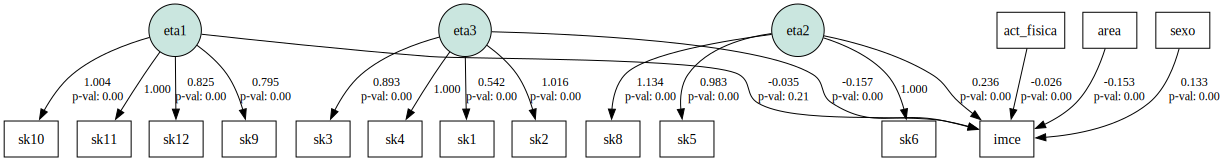

In [ ]:
semopy.semplot(model_cfa, "semmodel.png")

In [ ]:
model_cfa.predict_factors(data)